In [2]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import os
import glob
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import folium
import xarray as xr



In [3]:
def exibir_imagem_satelite(caminho_arquivo):
    try:
        with rasterio.open(caminho_arquivo) as src:
            print(f"--- Informações da Imagem ---")
            print(f"Número de bandas (canais): {src.count}")
            print(f"Largura x Altura: {src.width} x {src.height}")
            print(f"Sistema de Coordenadas (CRS): {src.crs}")
            print(f"Limites Geográficos: {src.bounds}")
            print(f"-----------------------------\n")
            
            fig, ax = plt.subplots(figsize=(10, 10))
            show(src, ax=ax, title="Visualização de Imagem de Satélite")
            
            plt.show()

    except FileNotFoundError:
        print(f"Erro: O arquivo '{caminho_arquivo}' não foi encontrado.")
    except rasterio.errors.RasterioIOError:
        print("Erro: O arquivo não é um GeoTIFF válido ou está corrompido.")
    except Exception as e:
        print(f"Ocorreu um erro inesperado: {e}")

--- Informações da Imagem ---
Número de bandas (canais): 3
Largura x Altura: 512 x 512
Sistema de Coordenadas (CRS): EPSG:3035
Limites Geográficos: BoundingBox(left=4803253.767643386, bottom=2800132.8706745785, right=4803765.986067579, top=2800645.089098772)
-----------------------------



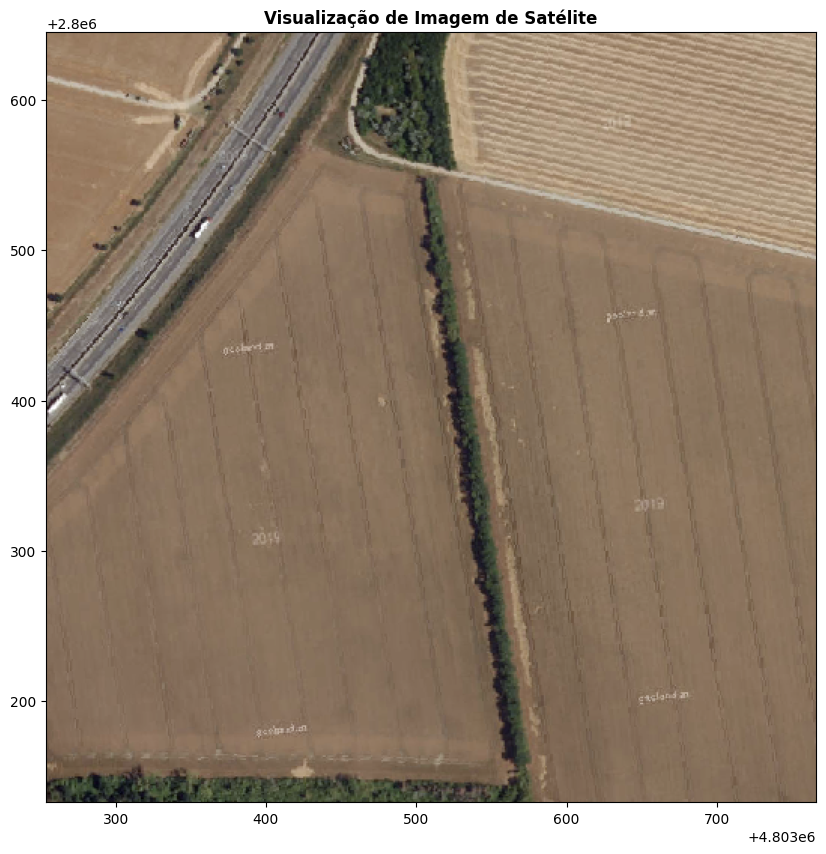

In [ ]:

meu_arquivo_satelite = 'dataset/orthophoto/images/AT/AT_9596_ortho_1m_512.tif' 
exibir_imagem_satelite(meu_arquivo_satelite)

--- Informações da Imagem ---
Número de bandas (canais): 4
Largura x Altura: 256 x 256
Sistema de Coordenadas (CRS): EPSG:3035
Limites Geográficos: BoundingBox(left=4294229.953575389, bottom=2663108.877767493, right=4296789.953575389, top=2665668.877767493)
-----------------------------



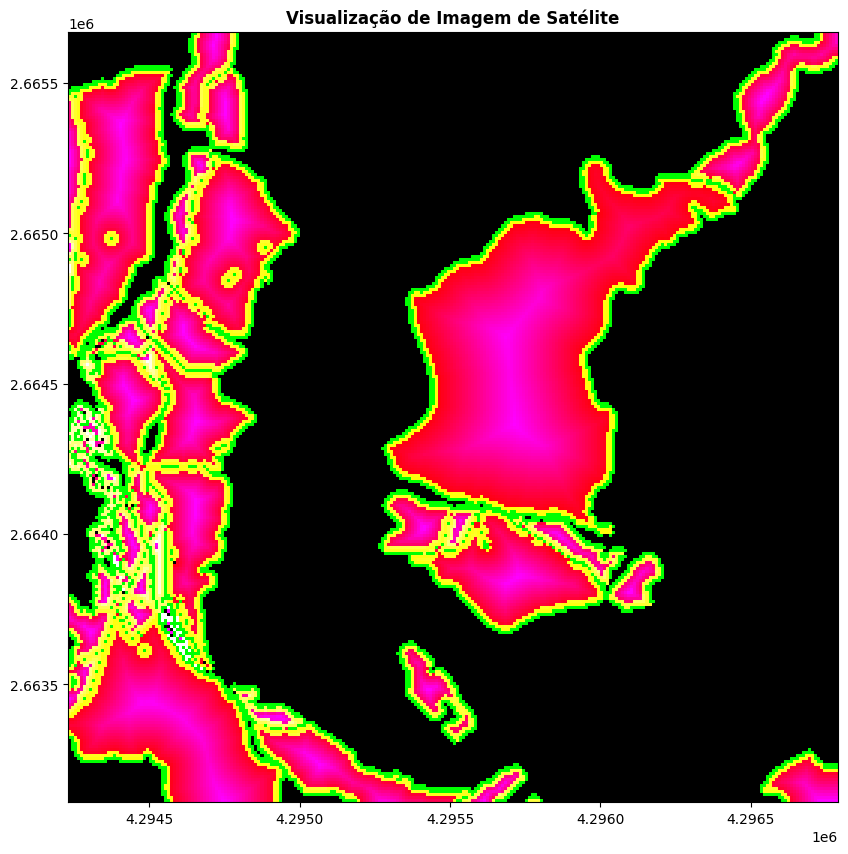

In [4]:
meu_arquivo_satelite = 'dataset/sentinel2/masks/AT/AT_164_S2label_10m_256.tif'
exibir_imagem_satelite(meu_arquivo_satelite)

In [ ]:


def plotar_area_tifs_recursivo(pasta_principal):
    caminho_busca = os.path.join(pasta_principal, '**', '*.tif')
    
    arquivos_tif = glob.glob(caminho_busca, recursive=True)

    if not arquivos_tif:
        print(f"Nenhum arquivo .tif encontrado na pasta principal ou em suas subpastas: {pasta_principal}")
        return

    lista_poligonos = []

    print(f"Encontrados {len(arquivos_tif)} arquivos em todas as pastas. Extraindo contornos...")

    for arquivo in arquivos_tif:
        try:
            with rasterio.open(arquivo) as src:
                limites = src.bounds
                geom = box(limites.left, limites.bottom, limites.right, limites.top)
                
                lista_poligonos.append({
                    'geometry': geom, 
                    'crs': src.crs, 
                    'nome': os.path.basename(arquivo)
                })
        except Exception as e:
            print(f"Erro ao ler {arquivo}: {e}")

    if not lista_poligonos:
        print("Não foi possível extrair a geometria de nenhuma imagem.")
        return

    print("Processando geometrias e calculando áreas...")

    gdfs_individuais = []
    for item in lista_poligonos:
        crs_atual = item['crs'] if item['crs'] else "EPSG:4326"
        gdf_temp = gpd.GeoDataFrame([item], geometry='geometry', crs=crs_atual)
        gdf_temp = gdf_temp.to_crs(epsg=4326)
        gdfs_individuais.append(gdf_temp)

    gdf_final = pd.concat(gdfs_individuais, ignore_index=True)

    gdf_projetado = gdf_final.to_crs(epsg=3857)
    
    area_mapeada_unida = gdf_projetado.unary_union
    area_total_m2 = area_mapeada_unida.area
    area_total_km2 = area_total_m2 / 1_000_000

    fig, ax = plt.subplots(figsize=(12, 8))
    
    gdf_final.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=1.5, alpha=0.6)

    plt.title(f"Mapeamento de TIFs (Busca em Subpastas)\nÁrea Única Total: ~{area_total_km2:.2f} km²", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle='--', color='gray', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
C:\Users\matos\AppData\Local\Temp\ipykernel_25424\928332918.py:3: SyntaxWarning: invalid escape sequence '\o'
  minha_pasta = 'dataset\orthophoto\images'


Encontrados 7596 arquivos em todas as pastas. Extraindo contornos...
Processando geometrias e calculando áreas...


C:\Users\matos\AppData\Local\Temp\ipykernel_25424\2210204303.py:53: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  area_mapeada_unida = gdf_projetado.unary_union


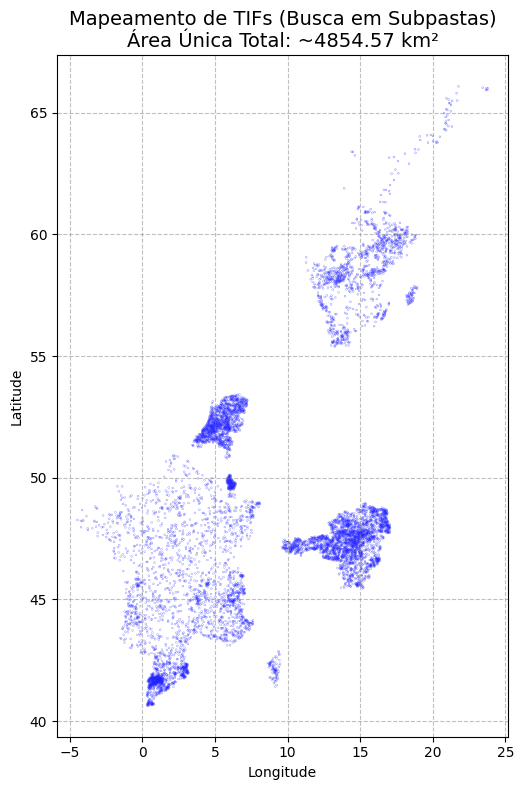

In [ ]:

minha_pasta = 'dataset\orthophoto\images'
plotar_area_tifs_recursivo(minha_pasta)

In [ ]:
def gerar_mapa_interativo(pasta_principal):
    caminho_busca = os.path.join(pasta_principal, '**', '*.tif')
    arquivos_tif = glob.glob(caminho_busca, recursive=True)

    if not arquivos_tif:
        print("Nenhum ficheiro .tif encontrado.")
        return

    poligonos = []
    
    print(f"A processar {len(arquivos_tif)} ficheiros...")

    for arquivo in arquivos_tif:
        try:
            with rasterio.open(arquivo) as src:
                b = src.bounds
                geom = box(b.left, b.bottom, b.right, b.top)
                
                gdf_temp = gpd.GeoDataFrame([{'nome': os.path.basename(arquivo)}], 
                                           geometry=[geom], 
                                           crs=src.crs)
                gdf_temp = gdf_temp.to_crs(epsg=4326)
                
                poligonos.append(gdf_temp)
        except Exception as e:
            print(f"Erro em {os.path.basename(arquivo)}: {e}")

    gdf_final = gpd.pd.concat(poligonos, ignore_index=True)

    centro = [gdf_final.geometry.centroid.y.mean(), gdf_final.geometry.centroid.x.mean()]

    m = folium.Map(location=centro, zoom_start=10, tiles='OpenStreetMap')

    folium.TileLayer(
        tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr = 'Esri',
        name = 'Satélite (Esri)',
        overlay = False,
        control = True
    ).add_to(m)

    folium.GeoJson(
        gdf_final,
        name='Áreas de Satélite',
        style_function=lambda x: {
            'fillColor': '#00ff00',
            'color': '#005500',
            'weight': 2,
            'fillOpacity': 0.3
        },
        tooltip=folium.GeoJsonTooltip(fields=['nome'], aliases=['Ficheiro:'])
    ).add_to(m)

    folium.LayerControl().add_to(m)

    nome_arquivo_mapa = "mapa_areas_satelite.html"
    m.save(nome_arquivo_mapa)
    
    print(f"\nSucesso! O mapa foi gerado: {nome_arquivo_mapa}")
    print("Basta abrir este ficheiro no teu Chrome ou Firefox.")

<>:80: SyntaxWarning: invalid escape sequence '\o'
<>:80: SyntaxWarning: invalid escape sequence '\o'
C:\Users\matos\AppData\Local\Temp\ipykernel_25424\1841641112.py:80: SyntaxWarning: invalid escape sequence '\o'
  pasta_raiz = 'dataset\orthophoto\images\AT'


A processar 2091 ficheiros...


C:\Users\matos\AppData\Local\Temp\ipykernel_25424\1841641112.py:42: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centro = [gdf_final.geometry.centroid.y.mean(), gdf_final.geometry.centroid.x.mean()]



Sucesso! O mapa foi gerado: mapa_areas_satelite.html
Basta abrir este ficheiro no teu Chrome ou Firefox.


In [21]:

pasta_raiz = 'dataset\sentinel2\images\AT'
gerar_mapa_interativo(pasta_raiz)

Nenhum ficheiro .tif encontrado.


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\matos\AppData\Local\Temp\ipykernel_25424\3184627307.py:1: SyntaxWarning: invalid escape sequence '\s'
  pasta_raiz = 'dataset\sentinel2\images\AT'


In [24]:

def gerar_mapa_interativo_nc(pasta_principal):
    caminho_busca = os.path.join(pasta_principal, '**', '*.nc')
    arquivos_nc = glob.glob(caminho_busca, recursive=True)

    if not arquivos_nc:
        print(f"Nenhum arquivo .nc encontrado na pasta principal ou subpastas: {pasta_principal}")
        return

    poligonos = []
    
    print(f"Encontrados {len(arquivos_nc)} arquivos .nc. Extraindo limites espaciais...")

    for arquivo in arquivos_nc:
        try:
            with xr.open_dataset(arquivo) as ds:
                
                coords = list(ds.coords.keys())
                
                lat_col = next((c for c in coords if c.lower() in ['lat', 'latitude', 'y']), None)
                lon_col = next((c for c in coords if c.lower() in ['lon', 'longitude', 'x']), None)
                
                if lat_col and lon_col:
                    min_y = float(ds[lat_col].min())
                    max_y = float(ds[lat_col].max())
                    min_x = float(ds[lon_col].min())
                    max_x = float(ds[lon_col].max())
                    
                    geom = box(min_x, min_y, max_x, max_y)
                    
                    gdf_temp = gpd.GeoDataFrame([{'nome': os.path.basename(arquivo)}], 
                                               geometry=[geom], 
                                               crs="EPSG:4326")
                    poligonos.append(gdf_temp)
                else:
                    print(f"Aviso: Coordenadas espaciais (lat/lon) não encontradas em {os.path.basename(arquivo)}")
                    
        except Exception as e:
            print(f"Erro ao tentar ler {os.path.basename(arquivo)}: {e}")

    if not poligonos:
        print("\nNão foi possível extrair a geometria de nenhum arquivo .nc para gerar o mapa.")
        return

    print("Gerando o mapa interativo...")

    gdf_final = pd.concat(poligonos, ignore_index=True)

    centro_y = gdf_final.geometry.centroid.y.mean()
    centro_x = gdf_final.geometry.centroid.x.mean()

    m = folium.Map(location=[centro_y, centro_x], zoom_start=6, tiles='OpenStreetMap')

    folium.TileLayer(
        tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr='Esri',
        name='Satélite (Esri)',
        overlay=False,
        control=True
    ).add_to(m)

    folium.GeoJson(
        gdf_final,
        name='Áreas dos Arquivos .nc',
        style_function=lambda x: {
            'fillColor': '#ff7800',  # Laranja para diferenciar dos TIFs
            'color': '#cc3300',
            'weight': 2,
            'fillOpacity': 0.4
        },
        tooltip=folium.GeoJsonTooltip(fields=['nome'], aliases=['Arquivo .nc:'])
    ).add_to(m)

    folium.LayerControl().add_to(m)

    nome_arquivo_mapa = "mapa_areas_netcdf.html"
    m.save(nome_arquivo_mapa)
    
    print(f"\nSucesso! O mapa foi salvo como: {nome_arquivo_mapa}")
    print("Abra este arquivo HTML no seu navegador (Chrome, Edge, Firefox, etc) para ver o resultado.")


In [25]:
pasta_raiz_nc = 'dataset\sentinel2\images'
gerar_mapa_interativo_nc(pasta_raiz_nc)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\matos\AppData\Local\Temp\ipykernel_25424\573231320.py:1: SyntaxWarning: invalid escape sequence '\s'
  pasta_raiz_nc = 'dataset\sentinel2\images'


Encontrados 4551 arquivos .nc. Extraindo limites espaciais...
Gerando o mapa interativo...


C:\Users\matos\AppData\Local\Temp\ipykernel_25424\4189766663.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centro_y = gdf_final.geometry.centroid.y.mean()
C:\Users\matos\AppData\Local\Temp\ipykernel_25424\4189766663.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centro_x = gdf_final.geometry.centroid.x.mean()



Sucesso! O mapa foi salvo como: mapa_areas_netcdf.html
Abra este arquivo HTML no seu navegador (Chrome, Edge, Firefox, etc) para ver o resultado.
